In [45]:
%load_ext autoreload
%autoreload 2

from helpers.benchmark_plotting import *

models = [
    'vggt',
    # 'vggt_ba',
    'vggt_ba_ref',
    # 'vggt_edge_canny_all_2000iter',
    # 'vggt_edge_canny_early_stop_loss',
    'vggt_edge_canny_final',
    # 'vggt_edge_canny_skip_mlp',
    # 'vggt_edge_canny_dino3',
    'vggt_edge_canny_still_ok?'

    # 'vggt_edge_canny_final_no_stop',
    # 'vggt_edge_canny_free_vars_100iter',
    # 'vggt_edge_canny_mlp_100iter',
    # 'vggt_edge_canny_mlp_100iter_',

    # 'vggt_edge_canny_mlp_paramz_100_iter',
    # 'vggt_edge_canny_mlp_paramzk_100iter',
    # 'vggt_edge_canny_mlp_paramzk_toff_100iter',
    # 'vggt_edge_canny_w2_25',
    # 'vggt_edge_canny_w2_40'
]
thr = 5

# add a method to discard images with high error at the end, useful fo NVS and not relevant for AUC
# can I log cameras with their error vs gt?

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


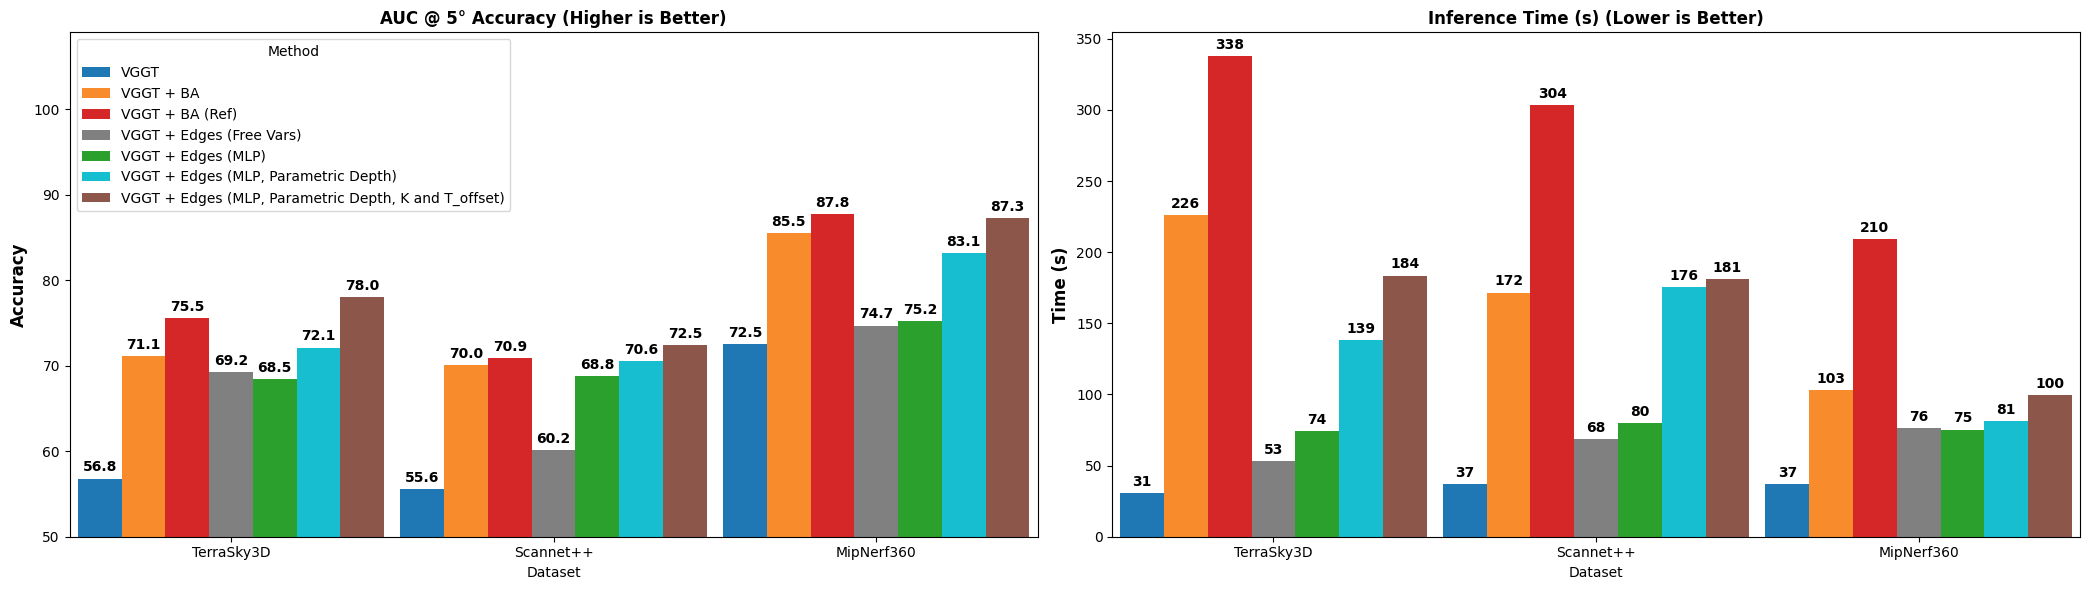

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

# 1. Load Data from JSON
with open("benchmark_results.json", "r") as f:
    results = json.load(f)

# Extract Datasets
datasets = results['metadata']['datasets']

# Initialize containers for reconstruction
auc_data = {'Dataset': datasets}
time_data = {'Dataset': datasets}
custom_palette = {}
method_order = []

# Parse experiments to populate data structures
for exp in results['experiments']:
    method_name = exp['method']
    
    # Append data
    auc_data[method_name] = exp['auc_scores']
    time_data[method_name] = exp['time_scores']
    
    # Map colors and order
    custom_palette[method_name] = exp['color']
    method_order.append(method_name)

# 2. Reshape Data for Plotting (Pandas Melt)
df_auc = pd.DataFrame(auc_data).melt(
    id_vars='Dataset', 
    var_name='Method', 
    value_name='AUC@5'
)

df_time = pd.DataFrame(time_data).melt(
    id_vars='Dataset', 
    var_name='Method', 
    value_name='Time (ms)'
)

# 3. Setup Figure
# sns.set_theme(style="whitegrid") # Optional: Uncomment for grid lines
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 6))

# --- Plot 1: AUC @ 5° ---
sns.barplot(
    data=df_auc, 
    x='Dataset', 
    y='AUC@5', 
    hue='Method', 
    width=0.95,
    hue_order=method_order, 
    ax=ax1, 
    palette=custom_palette, 
    saturation=1, 
    edgecolor=None, 
    linewidth=0
)

ax1.set_title('AUC @ 5° Accuracy (Higher is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(50, 109) # Adjusted Y-limit slightly for better fit

# NEW: Annotate AUC bars
for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f'{h:.1f}', 
                     (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', 
                     fontsize=10, fontweight='bold', 
                     xytext=(0, 8), textcoords='offset points')
        
# --- Plot 2: Inference Time ---
sns.barplot(
    data=df_time,            # Uses the reshaped time data
    x='Dataset', 
    y='Time (ms)', 
    hue='Method', 
    width=0.95,
    hue_order=method_order, 
    ax=ax2,                  # Plots on the right-hand chart (ax2)
    palette=custom_palette, 
    saturation=1, 
    edgecolor=None, 
    linewidth=0
)

ax2.set_title('Inference Time (s) (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Time (s)', fontsize=12, fontweight='bold')

# Annotate Time bars (putting the numbers on top of the bars)
for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f'{h:.0f}', 
                     (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', 
                     fontsize=10, fontweight='bold', 
                     xytext=(0, 8), textcoords='offset points')

# 4. Final Formatting
plt.tight_layout()
# Place legend on the first plot, remove from second to avoid duplication
ax1.legend(title='Method', loc='upper left', frameon=True)
if ax2.get_legend():
    ax2.get_legend().remove()

plt.show()

## TerraSky3D Test set

In [47]:
# w2 = 50
dataset = "terrasky3D"
df = read_results(dataset, "sparse_150", models, thr=thr)

Results:


,auc@5_vggt,auc@5_vggt_ba_ref,auc@5_vggt_edge_canny_final,auc@5_vggt_edge_canny_still_ok?,vggt,vggt+ba+ref,vggt+edge+canny+final,vggt+edge+canny+still+ok?
graz_church,72.1,87.4,86.3,86.1,37.9,1051.4,297.3,266.0
graz_townhall,18.8,65.9,68.3,66.6,42.4,229.0,196.5,198.9
graz_university,35.5,41.8,49.0,49.1,37.9,374.6,164.8,156.3
munich_frauenkirche,68.2,87.7,85.4,85.4,30.0,206.1,276.8,270.9
munich_marienplatz,55.3,78.6,67.8,67.7,40.1,257.5,117.7,89.7
munich_theatine_church,67.0,77.7,87.9,88.8,28.0,341.7,235.9,231.4
salzburg_andrakirche,70.6,76.1,84.6,82.9,26.1,203.1,156.8,70.4
salzburg_recthe_altstadt,68.8,93.5,91.3,90.7,9.5,91.1,85.8,89.0
vienna_state_opera,54.9,70.9,74.3,77.6,26.7,284.5,218.3,198.6
mean,56.8,75.5,77.2,77.2,31.0,337.7,194.4,174.6


In [48]:
print(latexfy(df, caption="", label=f"tab:{dataset}"))

\begin{table}[htbp]
    \centering
    \resizebox{\linewidth}{!}{
        \begin{tabular}{l cc cc cc cc }
            \toprule
             & \multicolumn{2}{c}{\textbf{VGGT}} & \multicolumn{2}{c}{\textbf{VGGT+BA+REF}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+FINAL}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+STILL+OK?}} \\
            \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
            \textbf{Scene} & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ \\
            \midrule
            Graz Church & 72.1 & 37.9 & \textbf{87.4} & 1051.4 & 86.3 & 297.3 & 86.1 & \textbf{266.0} \\
            Graz Townhall & 18.8 & 42.4 & 65.9 & 229.0 & \textbf{68.3} & \textbf{196.5} & 66.6 & 198.9 \\
            Graz University & 35.5 & 37.9 & 41.8 & 374.6 & 49.0 & 164.8 & \textbf{49.1} & \textbf{156.3} \\
            Munich Frauenkirche & 68.2 & 30.0 & \textb

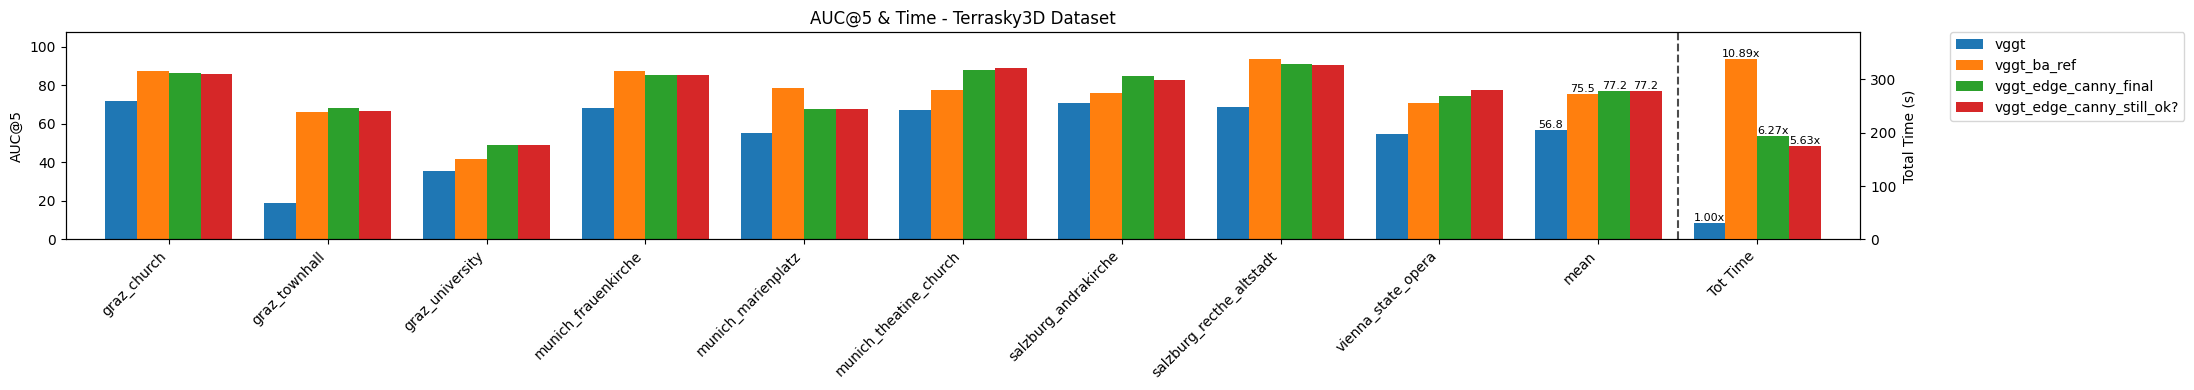

In [49]:
plot_auc5_with_time(df, dataset, models, thr)

## Scannet++

In [50]:
# w2 = 50
dataset = "scannetpp"
df = read_results(dataset, "sparse_150", models, thr=thr)

Results:


,auc@5_vggt,auc@5_vggt_ba_ref,auc@5_vggt_edge_canny_final,auc@5_vggt_edge_canny_still_ok?,vggt,vggt+ba+ref,vggt+edge+canny+final,vggt+edge+canny+still+ok?
09c1414f1b,40.1,66.8,53.7,54.0,40.3,335.6,174.4,171.3
1ada7a0617,48.5,64.8,62.5,63.1,36.8,304.4,189.0,175.9
21d970d8de,66.1,73.5,81.7,81.8,37.1,251.7,202.7,196.8
286b55a2bf,48.0,72.9,67.2,67.1,37.2,584.3,198.8,188.8
38d58a7a31,61.2,76.8,76.2,76.2,36.7,282.0,150.7,145.1
3e8bba0176,73.0,75.5,82.9,83.1,36.9,267.0,171.3,165.0
40aec5fffa,45.8,51.4,69.1,68.8,36.7,229.8,142.1,131.7
578511c8a9,50.9,65.3,56.7,54.0,36.8,497.3,180.8,180.5
5f99900f09,44.9,71.1,76.7,77.3,36.7,230.5,144.8,139.8
7831862f02,70.1,80.8,84.7,84.4,37.1,218.6,152.9,136.7


In [51]:
print(latexfy(df, caption="", label=f"tab:{dataset}"))

\begin{table}[htbp]
    \centering
    \resizebox{\linewidth}{!}{
        \begin{tabular}{l cc cc cc cc }
            \toprule
             & \multicolumn{2}{c}{\textbf{VGGT}} & \multicolumn{2}{c}{\textbf{VGGT+BA+REF}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+FINAL}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+STILL+OK?}} \\
            \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
            \textbf{Scene} & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ \\
            \midrule
            09C1414F1B & 40.1 & 40.3 & \textbf{66.8} & 335.6 & 53.7 & 174.4 & 54.0 & \textbf{171.3} \\
            1Ada7A0617 & 48.5 & 36.8 & \textbf{64.8} & 304.4 & 62.5 & 189.0 & 63.1 & \textbf{175.9} \\
            21D970D8De & 66.1 & 37.1 & 73.5 & 251.7 & 81.7 & 202.7 & \textbf{81.8} & \textbf{196.8} \\
            286B55A2Bf & 48.0 & 37.2 & \textbf{72.9} & 584.3 & 6

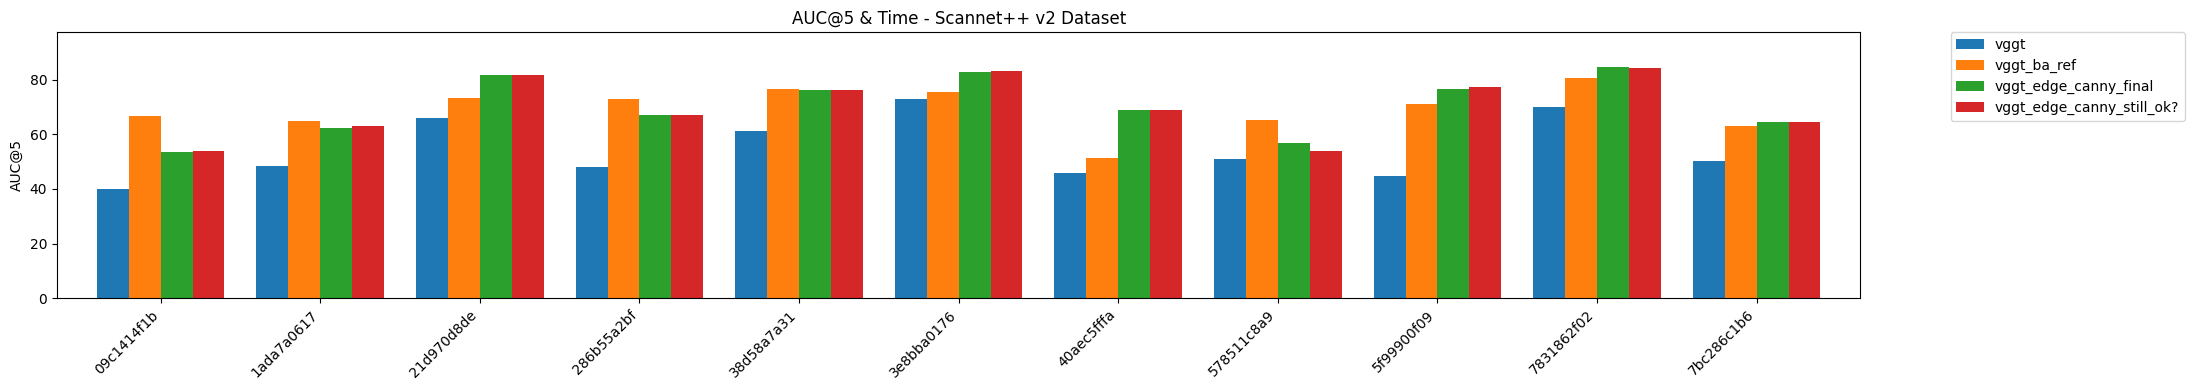

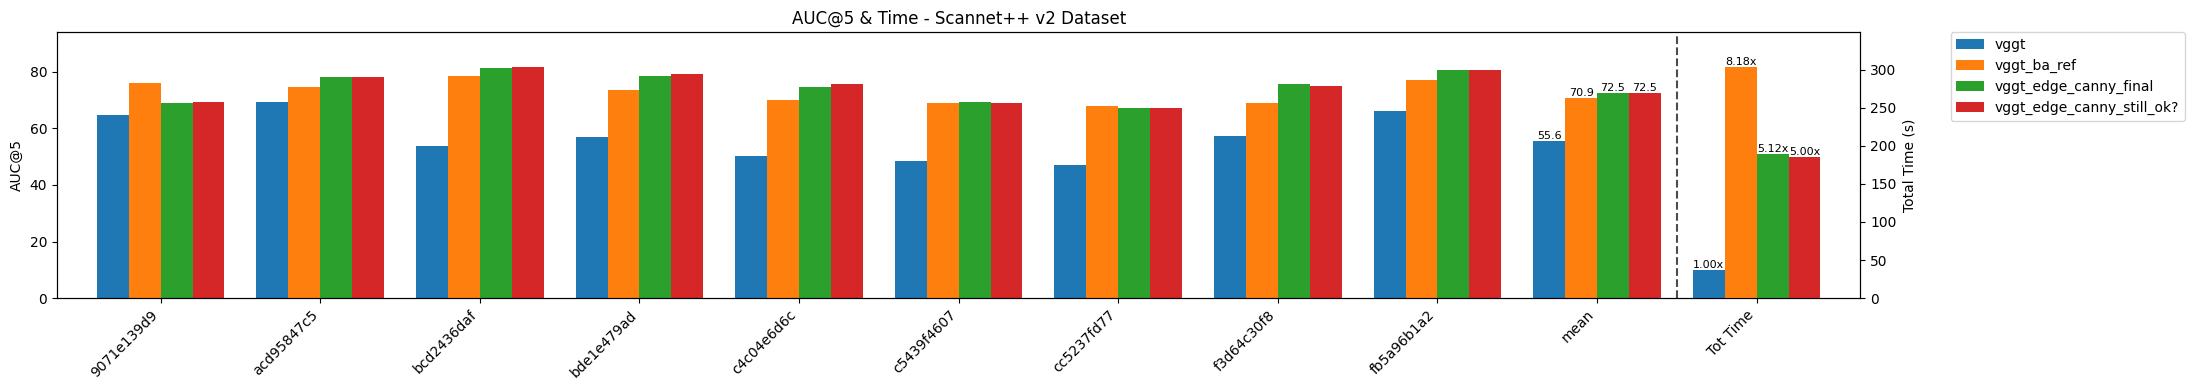

In [52]:
split = len(df) // 2 +1 
plot_auc5_with_time(df[:split], dataset, models, thr, ignore_time=True)
plot_auc5_with_time(df[split:], dataset, models, thr)

## MipNeRF360


In [53]:
# MLP (x|dino3 cls) seems to improve a bit
dataset = "mipnerf360"
df = read_results(dataset, "sparse_150", models, thr=thr, 
        remove=["stump", "treehill"], round_to=1
    )
# df.mean(numeric_only=True) # why?

Results:


,auc@5_vggt,auc@5_vggt_ba_ref,auc@5_vggt_edge_canny_final,auc@5_vggt_edge_canny_still_ok?,vggt,vggt+ba+ref,vggt+edge+canny+final,vggt+edge+canny+still+ok?
bicycle,77.8,86.5,87.2,86.4,44.0,179.8,138.2,124.4
bonsai,69.7,87.8,83.1,83.1,39.8,215.6,134.1,120.0
counter,83.5,94.6,93.7,93.3,40.8,249.3,105.0,103.1
flowers,34.3,70.7,78.5,79.8,43.0,177.2,142.6,159.0
garden,84.8,95.4,91.6,91.4,43.6,143.5,108.4,106.7
kitchen,87.8,88.7,94.3,94.1,41.0,224.0,86.9,80.2
room,68.6,91.9,89.1,89.5,41.1,281.9,91.1,87.2
mean,72.2,87.8,87.9,87.9,41.9,210.2,115.2,111.5


In [54]:
print(latexfy(df, caption="", label=f"tab:{dataset}"))

\begin{table}[htbp]
    \centering
    \resizebox{\linewidth}{!}{
        \begin{tabular}{l cc cc cc cc }
            \toprule
             & \multicolumn{2}{c}{\textbf{VGGT}} & \multicolumn{2}{c}{\textbf{VGGT+BA+REF}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+FINAL}} & \multicolumn{2}{c}{\textbf{VGGT+EDGE+CANNY+STILL+OK?}} \\
            \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
            \textbf{Scene} & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ & AUC@5 $\uparrow$ & Time $\downarrow$ \\
            \midrule
            Bicycle & 77.8 & 44.0 & 86.5 & 179.8 & \textbf{87.2} & 138.2 & 86.4 & \textbf{124.4} \\
            Bonsai & 69.7 & 39.8 & \textbf{87.8} & 215.6 & 83.1 & 134.1 & 83.1 & \textbf{120.0} \\
            Counter & 83.5 & 40.8 & \textbf{94.6} & 249.3 & 93.7 & 105.0 & 93.3 & \textbf{103.1} \\
            Flowers & 34.3 & 43.0 & 70.7 & 177.2 & 78.5 & \textbf{142.6} &

## MIPNeRF360 (NVS)

In [55]:
path = "/home/mattia/Desktop/Repos/gaussian-splatting/ablation/"
df = read_results_nvs(nvs_results_path=path, exclude_metrics=()).round(2)
df

method  0_free_vars             1_mlp_new             2_param_kz              \
               PSNR  SSIM LPIPS      PSNR  SSIM LPIPS       PSNR  SSIM LPIPS   
Scene                                                                          
Bicycle       18.41  0.45  0.45     18.56  0.44  0.45      18.67  0.45  0.44   
Bonsai        22.76  0.72  0.39     24.07  0.77  0.35      24.31  0.76  0.35   
Counter       25.66  0.82  0.26     24.27  0.77  0.29      24.22  0.77  0.29   
Flowers       16.19  0.34  0.51     16.12  0.32  0.52      16.14  0.32  0.52   
Garden        21.65  0.54  0.35     22.73  0.62  0.28      22.89  0.62  0.28   
Kitchen       22.78  0.72  0.25     21.43  0.65  0.29      22.42  0.68  0.27   
Room          26.34  0.81  0.34     26.52  0.82  0.31      26.68  0.82  0.31   
Mean          21.97  0.63  0.36     21.96  0.63  0.36      22.19  0.63  0.35   

method  3_toff             4_2000iter              
          PSNR  SSIM LPIPS       PSNR  SSIM LPIPS  
Scene                                              
Bicycle  18.95  0.47  0.43      19.34  0.50  0.41  
Bonsai   25.35  0.80  0.32      25.11  0.79  0.33  
Counter  26.22  0.84  0.24      25.95  0.83  0.25  
Flowers  16.79  0.36  0.49      17.25  0.40  0.46  
Garden   23.11  0.66  0.27      23.71  0.71  0.24  
Kitchen  23.99  0.77  0.21      24.79  0.83  0.20  
Room     27.73  0.84  0.30      28.29  0.86  0.29  
Mean     23.16  0.68  0.32      23.49  0.70  0.31

In [56]:
# path = "/home/mattia/Desktop/Repos/gaussian-splatting/ablation/"
df = read_results_nvs(
    exclude_metrics=(),
    column_order=["GT", "VGGT", "VGGT+BA", "VGGT+BA (Ref)", "VGGT+EA"]
    ).round(3)
df

method       GT                  VGGT                    BA                \
           PSNR   SSIM  LPIPS    PSNR   SSIM  LPIPS    PSNR   SSIM  LPIPS   
Scene                                                                       
Bicycle  21.766  0.685  0.271  16.775  0.357  0.524  18.737  0.453  0.444   
Bonsai   30.144  0.931  0.207  21.956  0.682  0.414  25.365  0.804  0.310   
Counter  27.983  0.896  0.195  22.977  0.719  0.334  25.490  0.814  0.278   
Flowers  20.691  0.624  0.319  14.856  0.269  0.612  17.414  0.375  0.467   
Garden   27.028  0.848  0.128  20.795  0.467  0.387  22.860  0.669  0.270   
Kitchen  28.828  0.927  0.116  20.686  0.595  0.333  20.614  0.652  0.333   
Room     30.394  0.903  0.229  25.857  0.797  0.349  28.403  0.859  0.275   
Mean     26.690  0.831  0.209  20.557  0.555  0.422  22.698  0.661  0.339   

method   BA_Ref                    EA                
           PSNR   SSIM  LPIPS    PSNR   SSIM  LPIPS  
Scene                                                
Bicycle  19.428  0.488  0.423  19.004  0.470  0.431  
Bonsai   25.504  0.816  0.303  25.803  0.806  0.315  
Counter  26.327  0.847  0.249  26.114  0.830  0.255  
Flowers  17.318  0.380  0.467  17.986  0.401  0.439  
Garden   23.730  0.733  0.222  23.887  0.688  0.246  
Kitchen  20.730  0.677  0.320  24.020  0.761  0.218  
Room     28.399  0.873  0.258  27.460  0.834  0.314  
Mean     23.062  0.688  0.320  23.468  0.684  0.317

In [57]:
format_dict = {col: ("{:.2f}" if "PSNR" in col[1] else "{:.3f}") for col in df.columns}
latex_str = df.style.format(format_dict).to_latex()
print(latex_str)

\begin{tabular}{lrrrrrrrrrrrrrrr}
method & \multicolumn{3}{r}{GT} & \multicolumn{3}{r}{VGGT} & \multicolumn{3}{r}{BA} & \multicolumn{3}{r}{BA_Ref} & \multicolumn{3}{r}{EA} \\
 & PSNR & SSIM & LPIPS & PSNR & SSIM & LPIPS & PSNR & SSIM & LPIPS & PSNR & SSIM & LPIPS & PSNR & SSIM & LPIPS \\
Scene &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
Bicycle & 21.77 & 0.685 & 0.271 & 16.77 & 0.357 & 0.524 & 18.74 & 0.453 & 0.444 & 19.43 & 0.488 & 0.423 & 19.00 & 0.470 & 0.431 \\
Bonsai & 30.14 & 0.931 & 0.207 & 21.96 & 0.682 & 0.414 & 25.36 & 0.804 & 0.310 & 25.50 & 0.816 & 0.303 & 25.80 & 0.806 & 0.315 \\
Counter & 27.98 & 0.896 & 0.195 & 22.98 & 0.719 & 0.334 & 25.49 & 0.814 & 0.278 & 26.33 & 0.847 & 0.249 & 26.11 & 0.830 & 0.255 \\
Flowers & 20.69 & 0.624 & 0.319 & 14.86 & 0.269 & 0.612 & 17.41 & 0.375 & 0.467 & 17.32 & 0.380 & 0.467 & 17.99 & 0.401 & 0.439 \\
Garden & 27.03 & 0.848 & 0.128 & 20.80 & 0.467 & 0.387 & 22.86 & 0.669 & 0.270 & 23.73 & 0.733 & 0.222 & 23.89 & 0.688 & 0.246 \\
Kitc

In [58]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

## MRE

In [ ]:
import glob
paths = sorted(glob.glob("benchmarks/vggt_edge_canny/*/*/sparse/training_logs.json"))

mre_ea = {}
# read all logs and print mean and median reprojection error per each of them
for p in paths:
    with open(p, "r") as f:
        log = json.load(f)
    mean_error = log["mean_reproj_error"]
    median_error = log["median_reproj_error"]
    # print(f"Path: {p.split('/')[2]}/{p.split('/')[3]}")
    # print(f"Mean Reprojection Error: {mean_error:.4f}")
    # print(f"Median Reprojection Error: {median_error:.4f}\n")
    mre_ea[f"{p.split('/')[2]}/{p.split('/')[3]}"] = mean_error
mre_ea

In [ ]:
import pycolmap
import numpy as np

def compute_mre_pycolmap(reconstruction):
    total_error = 0.0
    total_observations = 0
    
    # Iterate through all images in the reconstruction
    for image_id, image in reconstruction.images.items():
        # Only process registered images
        if not image.has_pose:
            continue
            
        camera = reconstruction.cameras[image.camera_id]
        
        # Get 2D-3D correspondences
        for point2D in image.points2D:
            # Check if point2D has a valid 3D point
            if not point2D.has_point3D():
                continue
            
            # Check if point3D_id is valid (not empty string)
            if not point2D.point3D_id or point2D.point3D_id not in reconstruction.points3D:
                continue
                
            # Get the 3D point coordinates
            point3D = reconstruction.points3D[point2D.point3D_id]
            
            # Project 3D point to camera frame
            # Convert Rigid3d to 4x4 matrix and apply transformation
            world_point_homo = np.append(point3D.xyz, 1.0)  # Convert to homogeneous coordinates
            cam_point_homo = image.cam_from_world.matrix() @ world_point_homo
            cam_coords = cam_point_homo[:3]  # Extract 3D coordinates
            
            # Project using camera model
            reprojected_2d = camera.img_from_cam(cam_coords)
            
            # Calculate reprojection error (L2 norm in pixels)
            observed_2d = point2D.xy
            error = np.linalg.norm(observed_2d - reprojected_2d)
            
            total_error += error
            total_observations += 1
                
    # Compute Mean Reprojection Error
    if total_observations == 0:
        return 0.0, 0
        
    mre = total_error / total_observations
    return mre, total_observations

# Usage:
paths = sorted(glob.glob("benchmarks/vggt_ba/*/*/sparse"))
mre_ba = {}
for path in paths:
    rec = pycolmap.Reconstruction(path)
    scene = f"{path.split('/')[2]}/{path.split('/')[3]}"
    if rec is not None:
        mre_value, count = compute_mre_pycolmap(rec)
        mre_ba[scene] = mre_value

paths = sorted(glob.glob("benchmarks/vggt_ba_ref/*/*/sparse"))
mre_ba_ref = {}
for path in paths:
    rec = pycolmap.Reconstruction(path)
    scene = f"{path.split('/')[2]}/{path.split('/')[3]}"
    if rec is not None:
        mre_value, count = compute_mre_pycolmap(rec)
        mre_ba_ref[scene] = mre_value


In [ ]:
import pandas as pd
mre_df = pd.DataFrame({
    "BA": pd.Series(mre_ba),
    "BA Refined": pd.Series(mre_ba_ref),
    "EA": pd.Series(mre_ea)
})
mre_df.loc['mean'] = mre_df.mean()  
mre_df.to_csv("benchmarks/mre_comparison.csv")

In [ ]:
mre_df

## batch

In [ ]:
dataset = "scannetpp"
remove = ["stump", "treehill"]

base_target = f"/home/mattia/Desktop/datasets/{dataset}"
base_repo = "/home/mattia/Desktop/Repos/batchsfm/benchmarks"
runs = os.listdir(base_repo)

scenes = os.listdir(base_target)
df = {}

for run in [f"vggt_edge_canny_{i}" for i in range(1,10)]:
    try:
        df_ = eval_colmap_model_all_scenes(
                    target_path=base_target,
                    target_folder="sparse_150",
                    input_path=f"{base_repo}/{run}/{dataset}",
                    input_folder="sparse",
                    return_df=True,
                    thrs=[thr],
                    round_to=4,
                    verbose=False,
                )
        # exclude "stump" and "treehill", the re do mean
        for rem in remove:
            df_.drop(rem, inplace=True, errors="ignore")
        df_.loc["mean"] = df_.mean()
        df[run] = df_.loc["mean"]
    except:
        pass

df = pd.DataFrame(df).T.round(2)

In [ ]:
df.loc['mean'] = df.mean().round(2)
df

In [ ]:
df['auc@5'].std()

In [ ]:
import pycolmap
path = "/home/mattia/Desktop/datasets/mipnerf360"

for scene in os.listdir(path)[1:]:
    if scene.startswith("."):
        continue
    scene_path = os.path.join(path, scene)

    # and do not start with .
    if not os.path.isdir(scene_path):
        continue

    # for images in ["images", "images_2", "images_4", "images_8"]:
    #     os.makedirs(os.path.join(scene_path, images, "1"), exist_ok=True)
    #     for img in os.listdir(os.path.join(scene_path, images)):
    #         if img.endswith(".JPG"):
    #             # print(f"Moving {img} to {os.path.join(scene_path, images, '1', img)}")
    #            os.rename(
    #                os.path.join(scene_path, images, img),
    #                os.path.join(scene_path, images, "1", img)
    #            )

    rec = pycolmap.Reconstruction(os.path.join(scene_path, "sparse/0"))
    # add 1/ to all images
    for img in rec.images.values():
        img.name = os.path.join("1", img.name)

    rec.write_binary(os.path.join(scene_path, "sparse/0"))

In [ ]:
from pathlib import Path
path = "/home/mattia/Desktop/datasets/mipnerf360"

for scene in os.listdir(path)[1:]:
    if scene.startswith("."):
        continue
    scene_path = os.path.join(path, scene)

    # and do not start with .
    if not os.path.isdir(scene_path):
        continue

    path_gt = f"/home/mattia/Desktop/datasets/mipnerf360/{scene}/images"
    path_train = f"/home/mattia/Desktop/datasets/mipnerf360/{scene}/images_4_150"

    def get_relative_paths(root_dir):
        root = Path(root_dir)
        # The rglob('*') method finds all files and directories recursively
        # We use .is_file() to filter out the directories themselves
        return [str(p.relative_to(root)) for p in root.rglob('*') if p.is_file()]

    # Example usage:
    images_gt = get_relative_paths(path_gt)
    images_train = get_relative_paths(path_train)

    compute_diff = sorted(list(set(images_gt) - set(images_train)))
    print(scene, len(compute_diff))

    with open(f"/home/mattia/Desktop/datasets/mipnerf360/{scene}/sparse/0/test.txt", "w") as f:
        for item in compute_diff:
            f.write("%s\n" % item)

In [ ]:
rec.images[1].camera

In [ ]:
rec = pycolmap.Reconstruction("/home/mattia/Desktop/Repos/batchsfm/benchmarks/vggt_edge_canny/mipnerf360/bicycle/sparse")
rec.cameras

In [ ]:
rec.cameras

In [ ]:
import pycolmap
rec = pycolmap.Reconstruction("/home/mattia/Desktop/datasets/mipnerf360/bicycle/sparse/0")
rec.cameras

# timings breakdown

In [ ]:
import pandas as pd
import re
import glob

def parse_timing_logs(file_paths):
    """
    Parses timing log files and returns a consolidated DataFrame.
    """
    data_list = []

    # Regex pattern to capture the key and the numeric value
    # Matches: [Key Name]: [Float Value]
    pattern = re.compile(r"^(.*?):\s*([\d.]+)")

    for path in file_paths:
        file_data = {"file_path": path.split('/')[-3]}  # Store relative file path
        try:
            with open(path, 'r') as f:
                for line in f:
                    match = pattern.search(line)
                    if match:
                        key = match.group(1).strip()
                        value = float(match.group(2))
                        file_data[key] = value
            data_list.append(file_data)
        except Exception as e:
            print(f"Error reading {path}: {e}")

    # Create DataFrame
    df = pd.DataFrame(data_list)
    
    # Move 'file_path' to the first column for better readability
    cols = ['file_path'] + [c for c in df.columns if c != 'file_path']
    return df[cols]

import glob
df = parse_timing_logs(glob.glob("benchmarks/vggt_edge_canny/mipnerf360/*/sparse/timings.txt"))
df

In [ ]:
df = parse_timing_logs(glob.glob("benchmarks/vggt_ba/mipnerf360/*/sparse/timings.txt"))
df

In [ ]:
df = parse_timing_logs(glob.glob("benchmarks/vggt_ba_ref/mipnerf360/*/sparse/timings.txt"))
df

In [ ]:
bars = {
    "VGGT+BA":{
        "vggt": 34.86,
        "tracks_establishment": 56.75,
        "optimizing": 3.02,
        "total": 113.02,
    },
    "VGGT+Ba (Ref)":{
        "vggt": 34.86,
        "tracks_establishment": 213.17,
        "optimizing": 4.4,
        "total": 281.89,
    },
    "VGGT+EA":{
        "vggt": 34.86,
        "loading_data": 4.445935,
        "optimizing": 45.566308-5.6722,
        "total": 50+34.86,
    },
}

# for all key, do the sum except "total"
for key, value in bars.items():
    value["other"] = value["total"] - sum(v for k, v in value.items() if k != "total")

bars

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Remove 'total' for plotting components
plot_data = {}
for category, segments in bars.items():
    plot_data[category] = {k: v for k, v in segments.items() if k != 'total'}

# Create DataFrame and fill missing values for specific segments with 0
df = pd.DataFrame(plot_data).T.fillna(0)

# Sort the categories by the sum of their segments
df['total_height'] = df.sum(axis=1)
df = df.sort_values(by='total_height')
df = df.drop(columns=['total_height'])

# Generate the stacked bar plot
ax = df.plot(kind='bar', stacked=True, figsize=(12, 7), rot=0)

plt.title('Cumulative Segment Breakdown per Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Time (s)', fontsize=12)
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()


In [ ]:

# Remove 'total' and prepare data
plot_data = {cat: {k: v for k, v in segs.items() if k != 'total'} for cat, segs in bars.items()}

# Create DataFrame
df = pd.DataFrame(plot_data).T.fillna(0)

# Normalize each row to sum to 100%
df_percent = df.div(df.sum(axis=1), axis=0) * 100

# Plotting
ax = df_percent.plot(kind='bar', stacked=True, figsize=(12, 7), rot=0, color=plt.cm.tab10.colors)

plt.title('Relative Segment Breakdown (Normalized to 100%)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100)

# Add percentage labels inside the bars
for p in ax.patches:
    height = p.get_height()
    if height > 3:  # Only label segments larger than 3%
        x, y = p.get_xy() 
        ax.text(x + p.get_width()/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import glob, json

paths = glob.glob("benchmarks/vggt_edge_canny_final/mipnerf360/*/sparse/training_logs.json")

steps = 0
for path in paths:
    with open(path, "r") as f:
        log = json.load(f)
    steps += log["steps_actual"]
    print(f"{path}: {log['steps_actual']} steps")

print("Average steps:", int(steps / len(paths)))


In [ ]:
log